# Benchmark Auswertung: Multiprocessing
Baseline vs. Static vs. Dynamic

Wird ausgeführt sobald alle drei Laptops ihre Ergebnisse gepusht haben.

#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from pathlib import Path

PROCESS_COUNTS = [1, 2, 4, 8]
IMAGE_COUNTS   = [100, 500, 1000, 5000]

colors  = {"Baseline": "green", "Static": "steelblue", "Dynamic": "darkorange", "Dynamic True": "purple"}
markers = {"Baseline": "^",     "Static": "o",         "Dynamic": "s",           "Dynamic True": "D"}
lines   = {1: "-", 2: "--", 3: ":"}

Path("results").mkdir(exist_ok=True)

#### 1. Daten laden

In [2]:
all_csvs = sorted(glob.glob("results/laptop*/*.csv")) #für alle laptops statt hardcoded Pfade
print(f"Gefundene CSVs: {len(all_csvs)}")
for f in all_csvs:
    print(f"  {f}")

df = pd.concat([pd.read_csv(f) for f in all_csvs], ignore_index=True) # Fügt mehrere DataFrames zusammen, Zeilenindex neu (sonst wäre mehrfach)
print(f"\nZeilen gesamt: {len(df)}")
df.groupby(["Laptop", "Variante", "Datensatz"])["Bilder"].count()



Gefundene CSVs: 9
  results/laptop1/results_baseline_laptop1.csv
  results/laptop1/results_dynamic_laptop1.csv
  results/laptop1/results_static_laptop1.csv
  results/laptop2/results_baseline_laptop2.csv
  results/laptop2/results_dynamic_laptop2.csv
  results/laptop2/results_static_laptop2.csv
  results/laptop3/results_baseline_laptop3.csv
  results/laptop3/results_dynamic_laptop3.csv
  results/laptop3/results_static_laptop3.csv

Zeilen gesamt: 216


Laptop  Variante  Datensatz       
1       Baseline  Kaggle Pneumonia     4
                  NIH                  4
        Dynamic   Kaggle Pneumonia    16
                  NIH                 16
        Static    Kaggle Pneumonia    16
                  NIH                 16
2       Baseline  Kaggle Pneumonia     4
                  NIH                  4
        Dynamic   Kaggle Pneumonia    16
                  NIH                 16
        Static    Kaggle Pneumonia    16
                  NIH                 16
3       Baseline  Kaggle Pneumonia     4
                  NIH                  4
        Dynamic   Kaggle Pneumonia    16
                  NIH                 16
        Static    Kaggle Pneumonia    16
                  NIH                 16
Name: Bilder, dtype: int64

#### 2. Laufzeit bei steigender Bildanzahl (alle Laptops)

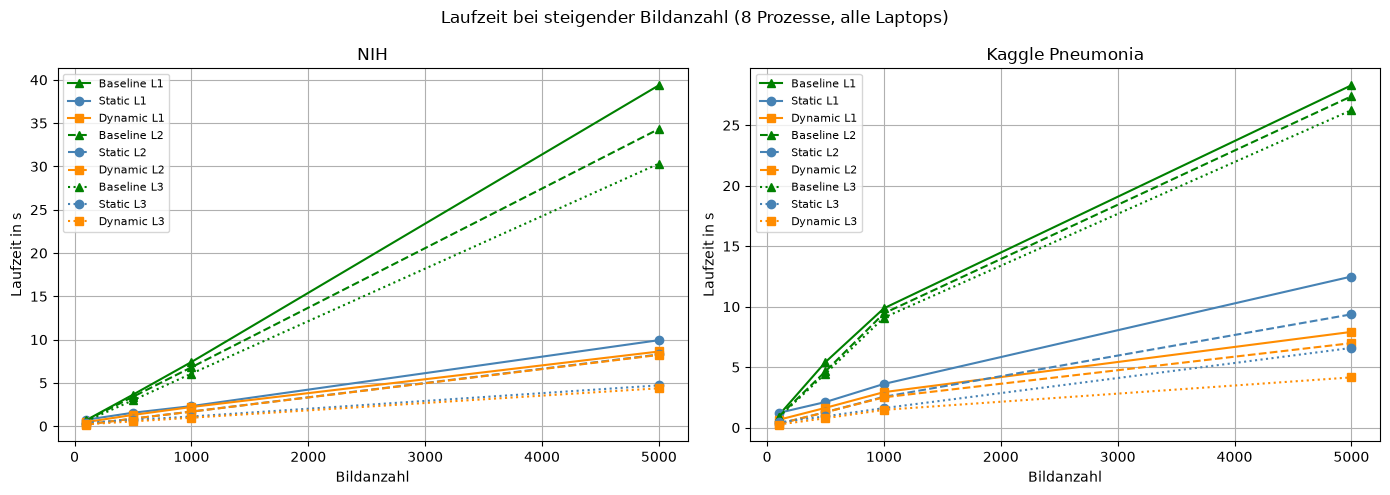

In [3]:
datasets = ["NIH", "Kaggle Pneumonia"]
laptops  = sorted(df["Laptop"].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Laufzeit bei steigender Bildanzahl (8 Prozesse, alle Laptops)")

for ax, ds in zip(axes, datasets): #Iteriert gleichzeitig über die zwei Subplots und die zwei Datensätze
    for laptop in laptops:
        for variant in ["Baseline", "Static", "Dynamic"]:
            sub = df[
                (df["Laptop"]    == laptop) &
                (df["Variante"]  == variant) &
                (df["Datensatz"] == ds) &
                (df["Prozesse"]  == (1 if variant == "Baseline" else 8)) #Baseline hat nur 1 Prozess, Static und Dynamic werden mit 8 Prozessen verglichen
            ]
            if not sub.empty:
                ax.plot(
                    sub["Bilder"], sub["Laufzeit in s"],
                    color=colors[variant],
                    marker=markers[variant],
                    linestyle=lines.get(laptop, "-"),
                    label=f"{variant} L{laptop}"
                )
    ax.set_title(ds)
    ax.set_xlabel("Bildanzahl")
    ax.set_ylabel("Laufzeit in s")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig("results/runtime_by_image_count_all_laptops.png", dpi=150)
plt.show()

Baseline liegt auf allen Laptops deutlich über Static und Dynamic. Das zeigt den klaren Gewinn durch Parallelisierung. Bei NIH braucht die Baseline bei 5000 Bildern ~30-39s, Static und Dynamic kommen auf ~8-10s —> Faktor 4-5 schneller. Bei Kaggle Pneumonia ähnlich, aber hier trennen sich Static und Dynamic: Static ist langsamer als Dynamic, weil variable Auflösungen zu Lastungleichgewicht/Flaschenhals führen. L3 ist auf beiden Datensätzen der schnellste Laptop (bei Dynamic Kaggle nur ~4s bei 5000 Bildern).

#### 3. Speedup — alle Laptops

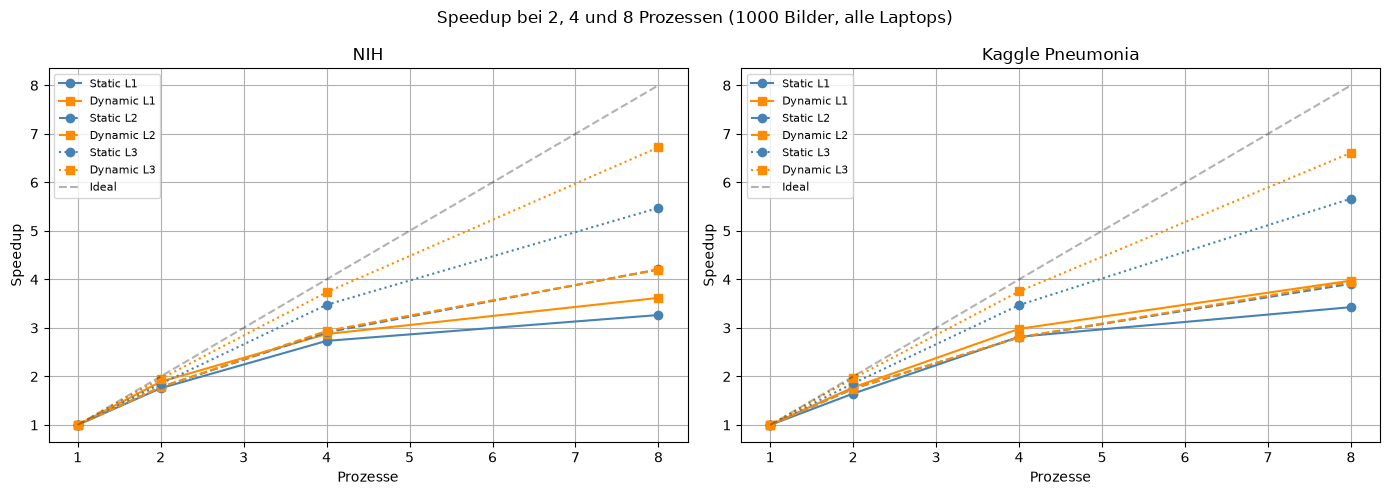

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Speedup bei 2, 4 und 8 Prozessen (1000 Bilder, alle Laptops)")

for ax, ds in zip(axes, datasets):
    for laptop in laptops:
        for variant in ["Static", "Dynamic"]:
            sub = df[
                (df["Laptop"]    == laptop) &
                (df["Variante"]  == variant) &
                (df["Datensatz"] == ds) &
                (df["Bilder"]    == 1000)
            ]
            if not sub.empty:
                ax.plot(
                    sub["Prozesse"], sub["Speedup"],
                    color=colors[variant],
                    marker=markers[variant],
                    linestyle=lines.get(laptop, "-"),
                    label=f"{variant} L{laptop}"
                )
    ax.plot(PROCESS_COUNTS, PROCESS_COUNTS, "k--", alpha=0.3, label="Ideal")
    ax.set_title(ds)
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Speedup")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig("results/speedup_by_processes_all_laptops.png", dpi=150)
plt.show()

Kein Laptop erreicht linearen Speedup. Bei 8 Prozessen maximal ~6.8 statt idealem 8. L1 und L2 liegen bei ~3.3-4.2, L3 deutlich höher bei ~5.5-6.8. Static und Dynamic liegen auf beiden Datensätzen eng beieinander. (Der Speedup-Plot ist nicht der beste um den Unterschied zwischen Static und Dynamic zu sehen, dafür ist der absolute Laufzeitplot besser geeignet.)

#### 4. Efficiency — alle Laptops

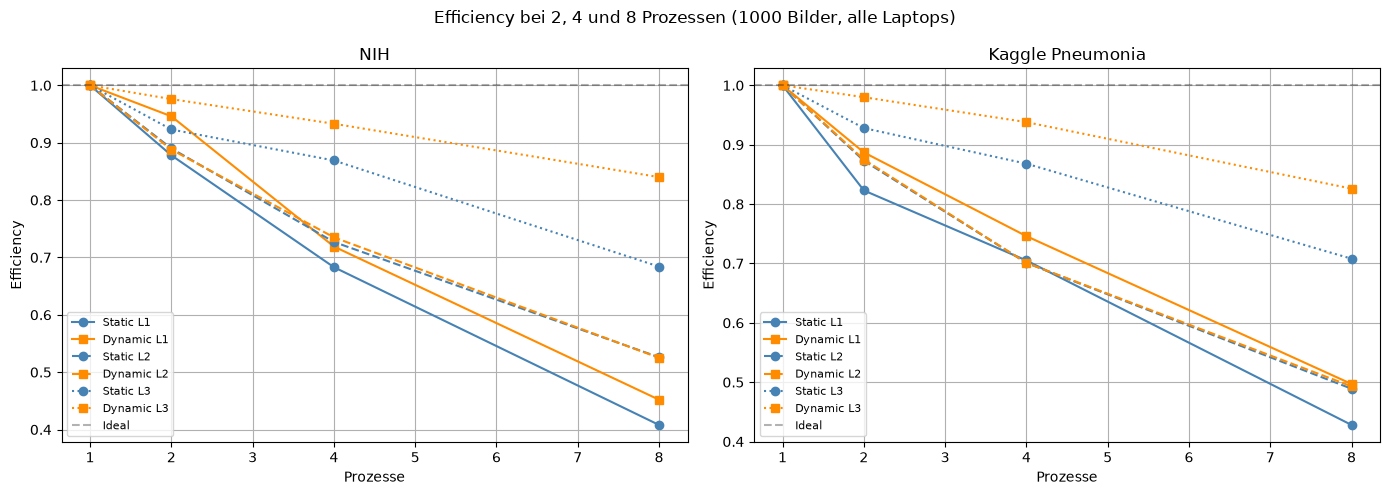

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Efficiency bei 2, 4 und 8 Prozessen (1000 Bilder, alle Laptops)")

for ax, ds in zip(axes, datasets):
    for laptop in laptops:
        for variant in ["Static", "Dynamic"]:
            sub = df[
                (df["Laptop"]    == laptop) &
                (df["Variante"]  == variant) &
                (df["Datensatz"] == ds) &
                (df["Bilder"]    == 1000)
            ]
            if not sub.empty:
                ax.plot(
                    sub["Prozesse"], sub["Efficiency"],
                    color=colors[variant],
                    marker=markers[variant],
                    linestyle=lines.get(laptop, "-"),
                    label=f"{variant} L{laptop}"
                )
    ax.axhline(1.0, color="k", linestyle="--", alpha=0.3, label="Ideal")
    ax.set_title(ds)
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Efficiency")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig("results/efficiency_by_processes_all_laptops.png", dpi=150)
plt.show()

Efficiency sinkt auf allen Laptops mit steigender Prozessanzahl. Bei 8 Prozessen liegt L1 und L2 bei ~41-53%, L3 hält ~84%. Das bedeutet bei L1 und L2 geht fast die Hälfte der CPU-Zeit durch Overhead verloren. Dynamic ist tendenziell etwas effizienter als Static, besonders bei Kaggle Pneumonia wo der Lastausgleich greift.

#### 5. Static vs. Dynamic vs. Baseline — alle Laptops

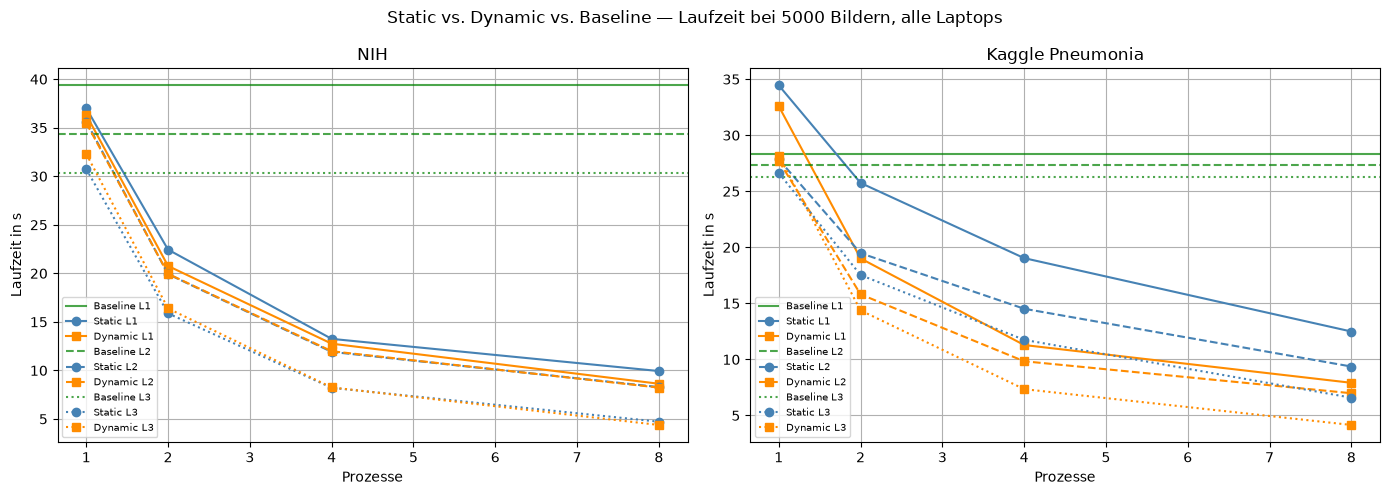

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Static vs. Dynamic vs. Baseline — Laufzeit bei 5000 Bildern, alle Laptops")

for ax, ds in zip(axes, datasets):
    for laptop in laptops:
        # Baseline — 1 Prozess
        sub_base = df[
            (df["Laptop"]    == laptop) &
            (df["Variante"]  == "Baseline") &
            (df["Datensatz"] == ds) &
            (df["Bilder"]    == 5000)
        ]
        if not sub_base.empty:
            ax.axhline(
                sub_base["Laufzeit in s"].values[0],
                color=colors["Baseline"],
                linestyle=lines.get(laptop, "-"),
                alpha=0.7,
                label=f"Baseline L{laptop}"
            )
        # Static und Dynamic
        for variant in ["Static", "Dynamic"]:
            sub = df[
                (df["Laptop"]    == laptop) &
                (df["Variante"]  == variant) &
                (df["Datensatz"] == ds) &
                (df["Bilder"]    == 5000)
            ]
            if not sub.empty:
                ax.plot(
                    sub["Prozesse"], sub["Laufzeit in s"],
                    color=colors[variant],
                    marker=markers[variant],
                    linestyle=lines.get(laptop, "-"),
                    label=f"{variant} L{laptop}"
                )
    ax.set_title(ds)
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Laufzeit in s")
    ax.legend(fontsize=7)
    ax.grid(True)

plt.tight_layout()
plt.savefig("results/static_vs_dynamic_all_laptops.png", dpi=150)
plt.show()

Bei NIH liegen Static und Dynamic eng beieinander, beide weit unter der Baseline. Bei Kaggle Pneumonia ist der Abstand zwischen Static und Dynamic klar sichtbar auf allen drei Laptops: Dynamic ist ~20-30% schneller als Static. Das bestätigt die Hypothese.

#### 6. Amdahls Gesetz

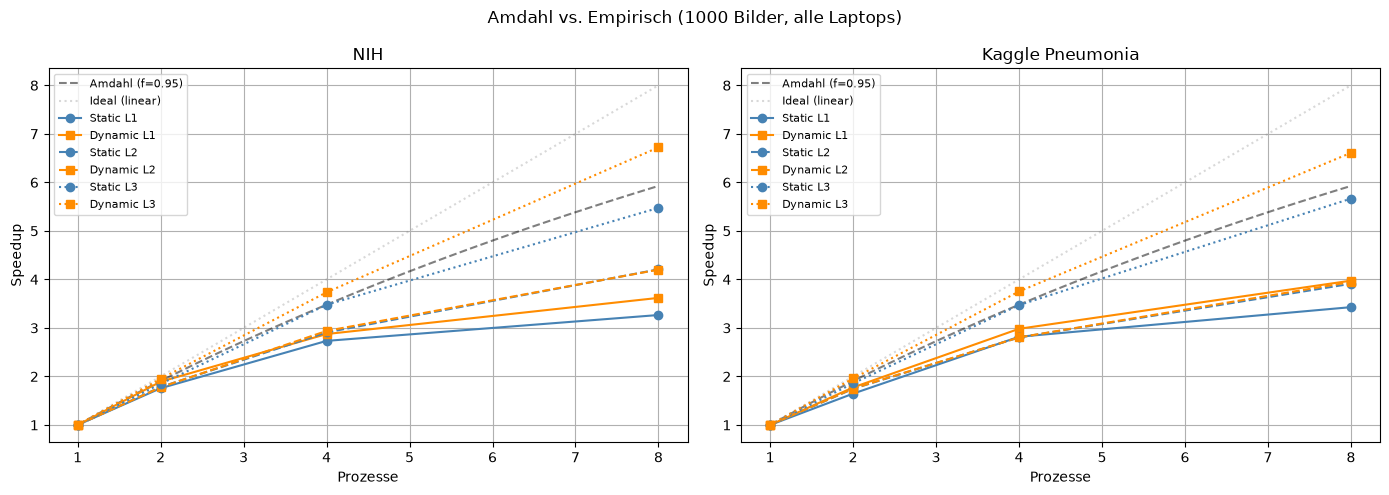

In [7]:
def amdahl(p, f=0.95): #f ist der parallelisierbare Anteil der Pipeline, 0.95 als Schätzwert weil Bildverarbeitung größtenteils parallelisierbar ist.
    return 1 / ((1 - f) + f / p)

p_range = np.linspace(1, 8, 100) #Erzeugt 100 gleichmäßig verteilte Punkte zwischen 1 und 8 damit Amdahl-Kurve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Amdahl vs. Empirisch (1000 Bilder, alle Laptops)")

for ax, ds in zip(axes, datasets):
    ax.plot(p_range, [amdahl(p) for p in p_range], "k--", alpha=0.5, label="Amdahl (f=0.95)")
    ax.plot(PROCESS_COUNTS, PROCESS_COUNTS, "gray", linestyle=":", alpha=0.3, label="Ideal (linear)")
    for laptop in laptops:
        for variant in ["Static", "Dynamic"]:
            sub = df[
                (df["Laptop"]    == laptop) &
                (df["Variante"]  == variant) &
                (df["Datensatz"] == ds) &
                (df["Bilder"]    == 1000)
            ]
            if not sub.empty:
                ax.plot(
                    sub["Prozesse"], sub["Speedup"],
                    color=colors[variant],
                    marker=markers[variant],
                    linestyle=lines.get(laptop, "-"),
                    label=f"{variant} L{laptop}"
                )
    ax.set_title(ds)
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Speedup")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig("results/amdahl_all_laptops.png", dpi=150)
plt.show()

L1 und L2 liegen unterhalb der Amdahl-Kurve mit f=0.95. Der sequenzieller Anteil ist größer als 5%, also mehr Overhead als angenommen. L3 Dynamic übertrifft die Amdahl-Kurve, d.h. die Hardware skaliert besser als das Modell vorhersagt.

#### 7. Ergebnistabelle

In [8]:
table = df[[
    "Laptop", "Variante", "Datensatz", "Bilder", "Prozesse",
    "Laufzeit in s", "Speedup", "Efficiency", "Throughput"
]].sort_values(["Laptop", "Variante", "Datensatz", "Bilder", "Prozesse"])

print(table.to_markdown(index=False))

|   Laptop | Variante   | Datensatz        |   Bilder |   Prozesse |   Laufzeit in s |   Speedup |   Efficiency |   Throughput |
|---------:|:-----------|:-----------------|---------:|-----------:|----------------:|----------:|-------------:|-------------:|
|        1 | Baseline   | Kaggle Pneumonia |      100 |          1 |           1.02  |     1     |        1     |        98.04 |
|        1 | Baseline   | Kaggle Pneumonia |      500 |          1 |           5.421 |     1     |        1     |        92.23 |
|        1 | Baseline   | Kaggle Pneumonia |     1000 |          1 |           9.865 |     1     |        1     |       101.37 |
|        1 | Baseline   | Kaggle Pneumonia |     5000 |          1 |          28.3   |     1     |        1     |       176.68 |
|        1 | Baseline   | NIH              |      100 |          1 |           0.704 |     1     |        1     |       142    |
|        1 | Baseline   | NIH              |      500 |          1 |           3.645 |     1     